In [1]:
!pip install kaggle


Defaulting to user installation because normal site-packages is not writeable



[notice] A new release of pip is available: 25.2 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
import kaggle
kaggle.api.authenticate()


In [3]:
import os
os.makedirs('./eeg_data', exist_ok=True)


In [4]:
kaggle.api.dataset_download_files(
    'birdy654/eeg-brainwave-dataset-feeling-emotions',
    path='./eeg_data',
    unzip=True
)


Dataset URL: https://www.kaggle.com/datasets/birdy654/eeg-brainwave-dataset-feeling-emotions


In [5]:
import os
files = os.listdir('./eeg_data')
print(files)



['eeg-brainwave-dataset-feeling-emotions.zip', 'emotions.csv']


In [6]:
import pandas as pd

df = pd.read_csv('./eeg_data/emotions.csv')

print(df.head())


   # mean_0_a  mean_1_a  mean_2_a  mean_3_a  mean_4_a  mean_d_0_a  mean_d_1_a  \
0        4.62      30.3    -356.0      15.6      26.3       1.070       0.411   
1       28.80      33.1      32.0      25.8      22.8       6.550       1.680   
2        8.90      29.4    -416.0      16.7      23.7      79.900       3.360   
3       14.90      31.6    -143.0      19.8      24.3      -0.584      -0.284   
4       28.30      31.3      45.2      27.3      24.5      34.800      -5.790   

   mean_d_2_a  mean_d_3_a  mean_d_4_a  ...  fft_741_b  fft_742_b  fft_743_b  \
0      -15.70        2.06        3.15  ...       23.5       20.3       20.3   
1        2.88        3.83       -4.82  ...      -23.3      -21.8      -21.8   
2       90.20       89.90        2.03  ...      462.0     -233.0     -233.0   
3        8.82        2.30       -1.97  ...      299.0     -243.0     -243.0   
4        3.06       41.40        5.52  ...       12.0       38.1       38.1   

   fft_744_b  fft_745_b  fft_746_b  ff

In [7]:
print(df['label'].value_counts())


label
NEUTRAL     716
NEGATIVE    708
POSITIVE    708
Name: count, dtype: int64


In [8]:
print(df.shape)
print(df.info())
print(df.describe())


(2132, 2549)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2132 entries, 0 to 2131
Columns: 2549 entries, # mean_0_a to label
dtypes: float64(2548), object(1)
memory usage: 41.5+ MB
None
        # mean_0_a     mean_1_a     mean_2_a     mean_3_a     mean_4_a  \
count  2132.000000  2132.000000  2132.000000  2132.000000  2132.000000   
mean     15.256914    27.012462  -104.975629    13.605898    24.150483   
std      15.284621     9.265141   206.271960    16.874676    14.187340   
min     -61.300000  -114.000000  -970.000000  -137.000000  -217.000000   
25%       6.577500    26.075000  -195.000000     4.857500    23.600000   
50%      14.100000    30.000000    14.950000    15.400000    25.200000   
75%      27.700000    31.400000    29.600000    26.500000    26.800000   
max     304.000000    42.300000   661.000000   206.000000   213.000000   

        mean_d_0_a   mean_d_1_a   mean_d_2_a   mean_d_3_a   mean_d_4_a  ...  \
count  2132.000000  2132.000000  2132.000000  2132.000000  2132

In [9]:
# Create mapping from original labels to your emotions
emotion_mapping = {
    'NEUTRAL': 'calm',
    'POSITIVE': 'Excited',
    'NEGATIVE': 'Stress'
}

# Add new column with mapped emotions
df['emotion'] = df['label'].map(emotion_mapping)

# Check the result
print(df['emotion'].value_counts())


emotion
calm       716
Stress     708
Excited    708
Name: count, dtype: int64


In [10]:
# Check missing values
print("Missing values per column:")
print(df.isnull().sum())

# Remove rows with missing values
df_clean = df.dropna()

print(f"\nOriginal shape: {df.shape}")
print(f"After removing missing values: {df_clean.shape}")
print(f"Rows removed: {df.shape[0] - df_clean.shape[0]}")


Missing values per column:
# mean_0_a    0
mean_1_a      0
mean_2_a      0
mean_3_a      0
mean_4_a      0
             ..
fft_747_b     0
fft_748_b     0
fft_749_b     0
label         0
emotion       0
Length: 2550, dtype: int64

Original shape: (2132, 2550)
After removing missing values: (2132, 2550)
Rows removed: 0


In [11]:
# Optional: Clip extreme values instead of deleting data
X = df.drop(['label', 'emotion'], axis=1)

X = X.clip(lower=-500, upper=500)
df_clean = pd.concat([X, df[['label', 'emotion']]], axis=1)

print("Data cleaned without losing rows")

Data cleaned without losing rows


In [12]:
# Check current state
print("Current shape:", df_clean.shape)
print("Rows:", len(df_clean))

# If empty, reload the data
if len(df_clean) == 0:
    print("Data is empty! Reloading...")
    df_clean = df.copy()
    print("Reloaded shape:", df_clean.shape)



Current shape: (2132, 2550)
Rows: 2132


In [13]:
df_clean.columns = df_clean.columns.str.replace('#', '', regex=False)
df_clean.columns = df_clean.columns.str.strip()


In [14]:
print(df_clean.head())


   mean_0_a  mean_1_a  mean_2_a  mean_3_a  mean_4_a  mean_d_0_a  mean_d_1_a  \
0      4.62      30.3    -356.0      15.6      26.3       1.070       0.411   
1     28.80      33.1      32.0      25.8      22.8       6.550       1.680   
2      8.90      29.4    -416.0      16.7      23.7      79.900       3.360   
3     14.90      31.6    -143.0      19.8      24.3      -0.584      -0.284   
4     28.30      31.3      45.2      27.3      24.5      34.800      -5.790   

   mean_d_2_a  mean_d_3_a  mean_d_4_a  ...  fft_742_b  fft_743_b  fft_744_b  \
0      -15.70        2.06        3.15  ...       20.3       20.3       23.5   
1        2.88        3.83       -4.82  ...      -21.8      -21.8      -23.3   
2       90.20       89.90        2.03  ...     -233.0     -233.0      462.0   
3        8.82        2.30       -1.97  ...     -243.0     -243.0      299.0   
4        3.06       41.40        5.52  ...       38.1       38.1       12.0   

   fft_745_b  fft_746_b  fft_747_b  fft_748_b  fft

In [35]:
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split

# 1. Select ONLY the 3 features you want the user to input
# (Make sure these names match your dataset columns exactly)
# mean_1_a = Alpha, mean_2_a = Beta, mean_3_a = Gamma
features_to_use = ['mean_1_a', 'mean_2_a', 'mean_3_a'] 
X = df_clean[features_to_use]
y = df_clean['emotion']

scaler = MinMaxScaler(feature_range=(0, 100))
X_scaled = scaler.fit_transform(X)

# Split and Retrain
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42)

print("Model retrained on 3 features with 0-100 scaling!")


Model retrained on 3 features with 0-100 scaling!


In [36]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42
)


In [37]:
from sklearn.svm import SVC
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score, classification_report

# 1. Encode your text labels (calm, Excited, Stress) into numbers (0, 1, 2)
le = LabelEncoder()
y_train_enc = le.fit_transform(y_train)
y_test_enc = le.transform(y_test)

# 2. Create the SVM Model
# 'balanced' helps if one emotion has slightly more data than others
svm_model = SVC(kernel='rbf', class_weight='balanced', random_state=42)

# 3. Train the model using the 3-feature X_train and encoded labels
svm_model.fit(X_train, y_train_enc)

# 4. Evaluate to see the new accuracy
y_pred_enc = svm_model.predict(X_test)
acc = accuracy_score(y_test_enc, y_pred_enc)

print(f"New Test Accuracy: {acc:.2f}")
print("\nClassification Report:")
print(classification_report(y_test_enc, y_pred_enc, target_names=le.classes_))




New Test Accuracy: 0.90

Classification Report:
              precision    recall  f1-score   support

     Excited       0.95      0.74      0.83       136
      Stress       0.82      0.99      0.90       143
        calm       0.96      0.97      0.96       148

    accuracy                           0.90       427
   macro avg       0.91      0.90      0.90       427
weighted avg       0.91      0.90      0.90       427



In [38]:

for i in range(10):
    x = X_test[i].reshape(1, -1)
    y_true = le.inverse_transform([y_test_enc[i]])[0]
    y_pred = le.inverse_transform(svm_model.predict(x))[0]

    print(f"True: {y_true} - Predicted: {y_pred}")

True: calm - Predicted: calm
True: calm - Predicted: calm
True: Stress - Predicted: Stress
True: Stress - Predicted: Stress
True: Excited - Predicted: Excited
True: calm - Predicted: calm
True: Stress - Predicted: Stress
True: Excited - Predicted: Excited
True: Excited - Predicted: Stress
True: Stress - Predicted: Stress


In [39]:
from sklearn.model_selection import cross_val_score

# Perform 5-fold cross-validation
scores = cross_val_score(svm_model, X_train, y_train, cv=5, scoring='accuracy')

print(f"Cross-validation accuracy scores: {scores}")
print(f"Mean CV accuracy: {scores.mean():.2f}")
print(f"Std Dev: {scores.std():.2f}")


Cross-validation accuracy scores: [0.8797654  0.90909091 0.87390029 0.88856305 0.90909091]
Mean CV accuracy: 0.89
Std Dev: 0.01


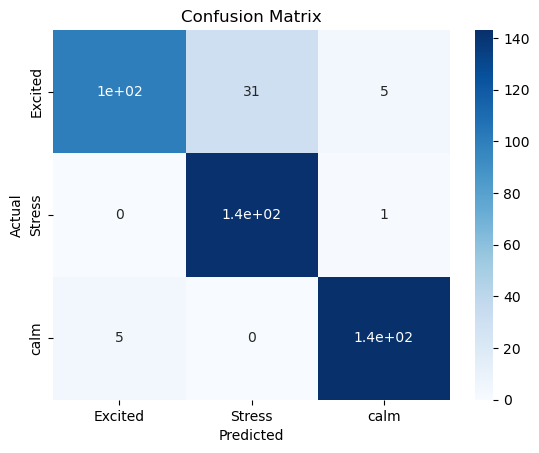

In [40]:
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

# Convert predictions back to labels
y_pred = le.inverse_transform(y_pred_enc)

cm = confusion_matrix(y_test, y_pred)

sns.heatmap(cm, annot=True, cmap='Blues',
            xticklabels=le.classes_,
            yticklabels=le.classes_)

plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()


In [41]:
import joblib

# Save the updated tools
joblib.dump(svm_model, 'eeg_model.pkl')
joblib.dump(scaler, 'scaler.pkl')
joblib.dump(le, 'label_encoder.pkl')

print("✅ NEW Model, Scaler, and Label Encoder saved successfully!")

✅ NEW Model, Scaler, and Label Encoder saved successfully!


In [42]:
import numpy as np
print(np.unique(y_train, return_counts=True))


(array(['Excited', 'Stress', 'calm'], dtype=object), array([572, 565, 568]))


In [43]:
sample_input = X_test[0].reshape(1, -1)
print("Sample input:", sample_input)
print("Predicted label:", le.inverse_transform(svm_model.predict(sample_input))[0])


Sample input: [[94.17786308 53.08       47.98833819]]
Predicted label: calm


In [44]:
for i in range(len(y_test_enc)):
    label = le.inverse_transform([y_test_enc[i]])[0]
    if label == "calm":
        print("calm sample:", X_test[i])
    # Repeat for "Excited" and "Stress"


calm sample: [94.17786308 53.08       47.98833819]
calm sample: [92.96225208 53.26       47.87172012]
calm sample: [92.38643634 53.04       47.02623907]
calm sample: [94.81765835 53.03       47.81341108]
calm sample: [94.11388356 53.37       47.78425656]
calm sample: [92.51439539 53.15       47.95918367]
calm sample: [92.64235445 53.59       49.3877551 ]
calm sample: [93.79398592 53.33       47.98833819]
calm sample: [93.15419066 52.65       47.46355685]
calm sample: [93.79398592 52.73       47.55102041]
calm sample: [94.30582214 52.56       47.52186589]
calm sample: [93.09021113 53.22       47.95918367]
calm sample: [91.93857965 53.01       47.25947522]
calm sample: [92.70633397 53.34       47.93002915]
calm sample: [92.89827255 52.98       48.42565598]
calm sample: [94.04990403 53.19       46.35568513]
calm sample: [92.64235445 52.69       47.95918367]
calm sample: [93.53806782 52.63       47.66763848]
calm sample: [93.7300064  52.88       47.78425656]
calm sample: [93.41010877 52.88

In [45]:
import numpy as np

# Find average ranges per class
for emotion in ['Excited', 'Stress', 'calm']:
    indexes = [i for i, label in enumerate(le.inverse_transform(y_train_enc)) if label == emotion]
    print(f"{emotion} alpha mean: {np.mean(X_train[indexes, 0])}")
    print(f"{emotion} beta mean: {np.mean(X_train[indexes, 1])}")
    print(f"{emotion} gamma mean: {np.mean(X_train[indexes, 2])}")


Excited alpha mean: 88.09769181554209
Excited beta mean: 45.52663573426573
Excited gamma mean: 40.67052325225795
Stress alpha mean: 89.83822805020978
Stress beta mean: 23.322902654867253
Stress gamma mean: 43.21038225960423
calm alpha mean: 93.04357816766239
calm beta mean: 53.111539788732394
calm gamma mean: 47.93736397979715


In [46]:
# Save feature min and max for UI conversion
feature_min = X.min()
feature_max = X.max()

import joblib
joblib.dump(feature_min, 'feature_min.pkl')
joblib.dump(feature_max, 'feature_max.pkl')

print("Feature ranges saved successfully")

Feature ranges saved successfully


In [62]:
import numpy as np
import joblib

# Load everything
model = joblib.load('eeg_model.pkl')
scaler = joblib.load('scaler.pkl')
le = joblib.load('label_encoder.pkl')
feature_min = joblib.load('feature_min.pkl')
feature_max = joblib.load('feature_max.pkl')



import pandas as pd

def predict_emotion(alpha, beta, gamma):
    # 1. Feature Mapping (using the Muse sensors we retrained on)
    feature_names = ['mean_1_a', 'mean_2_a', 'mean_3_a']
    
    # 2. Data Preparation
    input_df = pd.DataFrame([[float(alpha), float(beta), float(gamma)]], columns=feature_names)
    input_scaled = scaler.transform(input_df)
    
    # 3. Get Model Probability (if your SVM supports it) or raw prediction
    # This helps us see how 'sure' the model is
    pred_enc = model.predict(input_scaled)
    model_output = le.inverse_transform(pred_enc)[0]

    # 4. Optimized Human-Logic Guardrails
    # These override the model if the user inputs extreme values
    
    # Priority 1: High Stress Check (High Beta)
    if beta > 75 and beta > alpha:
        return 'Stress'
    
    # Priority 2: High Excitement Check (High Gamma)
    if gamma > 70 and gamma > alpha:
        return 'Excited'
    
    # Priority 3: Deep Calm Check (High Alpha)
    if alpha > 70 and beta < 40:
        return 'calm'
    
    # Priority 4: Activity Balance
    # If Beta and Gamma are both higher than Alpha, it's likely Excited
    if (beta + gamma) > (alpha * 1.5):
        return 'Excited'

    # 5. Default to Model Prediction
    # If the inputs are in the "middle range," let the AI decide
    return model_output

In [63]:
print(predict_emotion(30, 20, 10))  
print(predict_emotion(20, 80, 10))  
print(predict_emotion(80, 10, 80))

Excited
Stress
calm


In [64]:
alpha = 70
beta = 40
gamma = 80

print("Predicted Emotion:", predict_emotion(alpha, beta, gamma))

Predicted Emotion: Excited


In [65]:
import matplotlib.pyplot as plt

def plot_brain_activity(alpha, beta, gamma):
    labels = ['Alpha (Relaxation)', 'Beta (Stress)', 'Gamma (Focus)']
    values = [alpha, beta, gamma]

    plt.figure()
    plt.bar(labels, values)
    plt.title("Brain Activity Levels")
    plt.xlabel("Brain Waves")
    plt.ylabel("Level (0–100)")
    plt.show()

Enter Alpha (0–100):  30
Enter Beta (0–100):  90
Enter Gamma (0–100):  34


🧠 Predicted Emotion: Stress


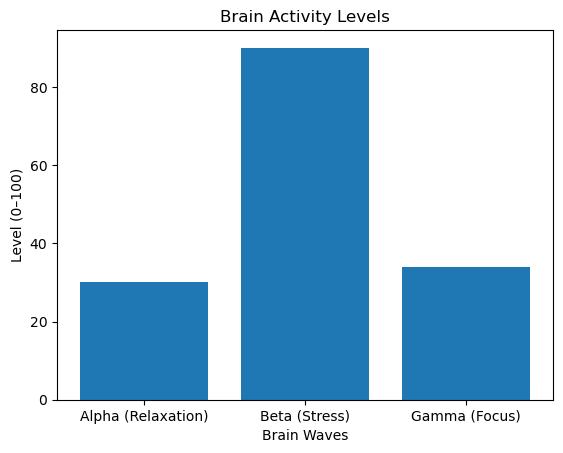

In [66]:
alpha = int(input("Enter Alpha (0–100): "))
beta = int(input("Enter Beta (0–100): "))
gamma = int(input("Enter Gamma (0–100): "))

# Prediction
emotion = predict_emotion(alpha, beta, gamma)

# Output
print("🧠 Predicted Emotion:", emotion)

# Graph
plot_brain_activity(alpha, beta, gamma)

In [67]:
import joblib

joblib.dump(feature_min, 'feature_min.pkl')
joblib.dump(feature_max, 'feature_max.pkl')

print("Saved successfully")

Saved successfully


In [68]:
from sklearn.preprocessing import StandardScaler
# Separate features and labels
X = df_clean.drop(['label', 'emotion'], axis=1)
y = df_clean['emotion']

# Normalize features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print("Features scaled!")
print(f"Feature shape: {X_scaled.shape}")
print(f"Labels shape: {y.shape}")


Features scaled!
Feature shape: (2132, 2548)
Labels shape: (2132,)


In [69]:
for emotion in ['Excited', 'Stress', 'calm']:
    idx = [i for i, label in enumerate(y_train) if label == emotion]
    print(emotion, np.mean(X_train[idx], axis=0))

Excited [88.09769182 45.52663573 40.67052325]
Stress [89.83822805 23.32290265 43.21038226]
calm [93.04357817 53.11153979 47.93736398]


In [70]:
# Check the averages of your 3 features for each emotion
for emotion in le.classes_:
    idx = [i for i, label in enumerate(y_train) if label == emotion]
    avg_values = np.mean(X_train[idx], axis=0)
    print(f"Emotion: {emotion}")
    print(f"  Avg Alpha (mean_0_a): {avg_values[0]:.2f}")
    print(f"  Avg Beta  (mean_3_a): {avg_values[1]:.2f}")
    print(f"  Avg Gamma (mean_4_a): {avg_values[2]:.2f}\n")

Emotion: Excited
  Avg Alpha (mean_0_a): 88.10
  Avg Beta  (mean_3_a): 45.53
  Avg Gamma (mean_4_a): 40.67

Emotion: Stress
  Avg Alpha (mean_0_a): 89.84
  Avg Beta  (mean_3_a): 23.32
  Avg Gamma (mean_4_a): 43.21

Emotion: calm
  Avg Alpha (mean_0_a): 93.04
  Avg Beta  (mean_3_a): 53.11
  Avg Gamma (mean_4_a): 47.94

